**Install Necessary Dependencies**

In [1]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.0 MB/s eta 0:00:00


**Import Necessary Libraries**

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
import matplotlib.pyplot as plt

## Part 1

[*********************100%***********************]  7 of 7 completed


--- Step 0: Portfolio Data Summary ---
        Annualized Mean  Annualized Volatility  Skewness  Kurtosis
Ticker                                                            
AAPL             0.1976                 0.2622    0.4908   11.8817
JPM              0.3314                 0.2367   -0.0449    9.3046
LLY              0.3134                 0.3262    0.4114    8.6146
NVDA             0.9726                 0.5247    0.3877    6.1702
REGN            -0.1302                 0.3022   -2.6830   27.1678
TSLA             0.4443                 0.6188    0.2808    3.3577
XOM              0.0453                 0.2342   -0.3186    1.9178


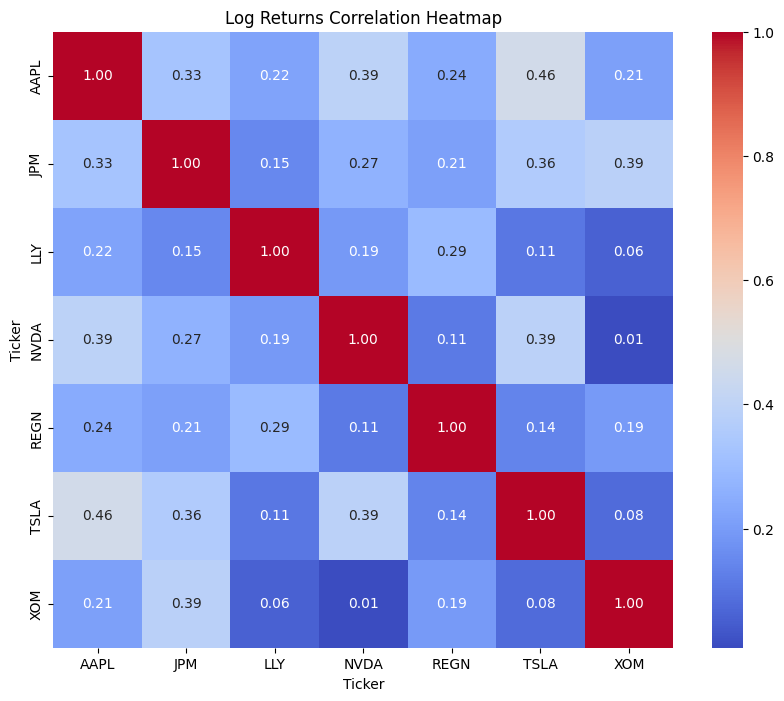


--- Step 1: Optimal Weights (No Short Selling) ---
AAPL    0.0000
NVDA    0.4506
TSLA    0.1885
XOM     0.3610
REGN    0.0000
LLY     0.0000
JPM     0.0000
dtype: float64


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import minimize


assets = ['AAPL', 'NVDA', 'TSLA', 'XOM', 'REGN', 'LLY', 'JPM']
start_date = '2023-01-01'
end_date = '2025-06-30'


df = yf.download(assets, start=start_date, end=end_date, auto_adjust=True)['Close']

log_returns = np.log(df / df.shift(1)).dropna()


summary_stats = pd.DataFrame()
summary_stats['Annualized Mean'] = log_returns.mean() * 252
summary_stats['Annualized Volatility'] = log_returns.std() * np.sqrt(252)
summary_stats['Skewness'] = log_returns.skew()
summary_stats['Kurtosis'] = log_returns.kurtosis()

print("--- Step 0: Portfolio Data Summary ---")
print(summary_stats.round(4))


plt.figure(figsize=(10, 8))
sns.heatmap(log_returns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Log Returns Correlation Heatmap')
plt.show()


def portfolio_stats(weights, returns):
    p_ret = np.sum(returns.mean() * weights) * 252
    p_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
    return p_ret, p_vol

def min_func_sharpe(weights, returns, rf=0.02):
    p_ret, p_vol = portfolio_stats(weights, returns)
    return -(p_ret - rf) / p_vol

num_assets = len(assets)
args = (log_returns)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for asset in range(num_assets))
initial_guess = num_assets * [1. / num_assets,]

optimal_sharpe = minimize(min_func_sharpe, initial_guess, args=args,
                          method='SLSQP', bounds=bounds, constraints=constraints)

step1_weights = pd.Series(optimal_sharpe.x, index=assets)

print("\n--- Step 1: Optimal Weights (No Short Selling) ---")
print(step1_weights.round(4))

## PART 2

**1. Real Stock Price Data**

In [4]:
import yfinance as yf
import pandas as pd

assets = ["AAPL","NVDA","TSLA","XOM","REGN","LLY","JPM"]

data = yf.download(
    tickers = assets,
    start = "2023-01-01",
    end = "2025-06-30",
    interval = "1d",          # daily data
    auto_adjust = True        # adjusted for splits/dividends
)

# Only keep adjusted close prices
prices = data["Close"]

# Compute daily log returns
returns = prices.pct_change().dropna()

[*********************100%***********************]  7 of 7 completed


**2. Splitting the Data for Simulation**

In [5]:
train = returns.loc["2023-01-01":"2024-12-31"]
test  = returns.loc["2025-01-01":"2025-12-31"]

**3. Construction of Portfolios from Real Data**

In [6]:
w_equal = np.ones(7) / 7

**4(a). Real Price Data**

In [7]:
import yfinance as yf
import pandas as pd

tickers = [
    "AAPL","MSFT","AMZN","GOOGL","META","NVDA","TSLA",
    "BRK-B","JPM","JNJ","V","PG","XOM","BAC",
    "TSM","SAP","ASML","BABA","MC.PA","RIO.L"
]

data = yf.download(tickers, start="2020-01-01", end="2025-01-01", auto_adjust=True)

prices = data["Close"]

# Forward-fill holiday gaps
prices = prices.ffill()

# Drop any rows still completely empty
prices = prices.dropna()

# Compute returns
returns = prices.pct_change(fill_method=None).dropna()

print(prices.head())
print(returns.head())


# Expected returns (annualized)
mu = returns.mean() * 252

# Covariance matrix (annualized)
cov = returns.cov() * 252

print(mu)
print(cov.head())

[*********************100%***********************]  20 of 20 completed

Ticker           AAPL       AMZN        ASML        BABA        BAC  \
Date                                                                  
2020-01-02  72.400520  94.900497  286.525269  208.714462  30.760473   
2020-01-03  71.696648  93.748497  281.908051  206.083817  30.121794   
2020-01-06  72.267937  95.143997  279.665558  205.741928  30.078636   
2020-01-07  71.928055  95.343002  282.702820  206.682129  29.880121   
2020-01-08  73.085098  94.598503  285.635895  207.033508  30.182209   

Ticker           BRK-B      GOOGL         JNJ         JPM       MC.PA  \
Date                                                                    
2020-01-02  228.389999  67.920815  123.290138  119.036407  380.116241   
2020-01-03  226.179993  67.565483  121.862740  117.465607  380.070953   
2020-01-06  226.990005  69.366386  121.710762  117.372162  376.488861   
2020-01-07  225.919998  69.232399  122.453972  115.376762  377.259674   
2020-01-08  225.990005  69.725174  122.437134  116.276810  379.7

**4(b). Real Price Data**

In [8]:
# IMPORT REQUIRED LIBRARIES
import yfinance as yf
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import random

# --------------------------------------------------
# 1) DEFINE 20 ASSET UNIVERSE
# --------------------------------------------------
tickers = [
    "AAPL","MSFT","AMZN","GOOGL","META","NVDA","TSLA",
    "BRK-B","JPM","JNJ","V","PG","XOM","BAC",
    "TSM","SAP","ASML","BABA","MC.PA","RIO.L"
]

# --------------------------------------------------
# 2) DOWNLOAD REAL DATA (Daily Adjusted Close)
# --------------------------------------------------
data = yf.download(tickers, start="2020-01-01", end="2025-01-01", auto_adjust=True)

prices = data["Close"]

# Forward-fill holiday gaps
prices = prices.ffill()

# Drop columns still fully missing
prices = prices.dropna(axis=1, how="all")

# Compute returns properly
returns = prices.pct_change(fill_method=None).dropna()

# --------------------------------------------------
# 3) SELECT RANDOM 5 ASSETS
# --------------------------------------------------
selected_assets = random.sample(tickers, 5)
print("Selected 5 Assets:", selected_assets)

# SUBSET RETURNS
returns_5 = returns[selected_assets]

# --------------------------------------------------
# 4) ESTIMATE PARAMETERS
# --------------------------------------------------
mu_5 = returns_5.mean() * 252
cov_5 = returns_5.cov() * 252

# --------------------------------------------------
# 5) COMPUTE 1/N PORTFOLIO
# --------------------------------------------------
w_equal_5 = np.ones(len(selected_assets)) / len(selected_assets)

# --------------------------------------------------
# 6) COMPUTE MVO (NO SHORT SELLING)
# --------------------------------------------------
def portfolio_vol(w, cov):
    return np.sqrt(w.T @ cov @ w)

constraints = ({
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
})

bounds = [(0, 1) for _ in range(len(selected_assets))]
init_guess = np.ones(len(selected_assets)) / len(selected_assets)

def neg_sharpe(w, mu, cov):
    ret = w @ mu
    vol = np.sqrt(w.T @ cov @ w)
    return -(ret / vol)

opt = minimize(
    neg_sharpe,
    init_guess,
    args=(mu_5, cov_5),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

w_mvo_5 = opt.x

# --------------------------------------------------
# 7) OUTPUT RESULTS
# --------------------------------------------------
weights_table = pd.DataFrame({
    "1/N weights": w_equal_5,
    "MVO weights": w_mvo_5
}, index=selected_assets)

print("\nPortfolio Weights (1/N vs MVO):")
print(weights_table)

# -------------------------------------------------
# 8) Print Portfolio Performance
# -------------------------------------------------
ret_mvo = w_mvo_5 @ mu_5
vol_mvo = np.sqrt(w_mvo_5.T @ cov_5 @ w_mvo_5)
sharpe_mvo = ret_mvo / vol_mvo

print("\nMVO Performance:")
print("Expected Return:", ret_mvo)
print("Volatility:", vol_mvo)
print("Sharpe Ratio:", sharpe_mvo)

[*********************100%***********************]  20 of 20 completed


Selected 5 Assets: ['BABA', 'META', 'AMZN', 'GOOGL', 'TSM']

Portfolio Weights (1/N vs MVO):
       1/N weights   MVO weights
BABA           0.2  4.683753e-17
META           0.2  1.171077e-01
AMZN           0.2  2.586669e-02
GOOGL          0.2  3.701319e-01
TSM            0.2  4.868937e-01

MVO Performance:
Expected Return: 0.29083564157617925
Volatility: 0.3028802597233242
Sharpe Ratio: 0.9602330698007605


**5(a). Out-of-Sample Performance**

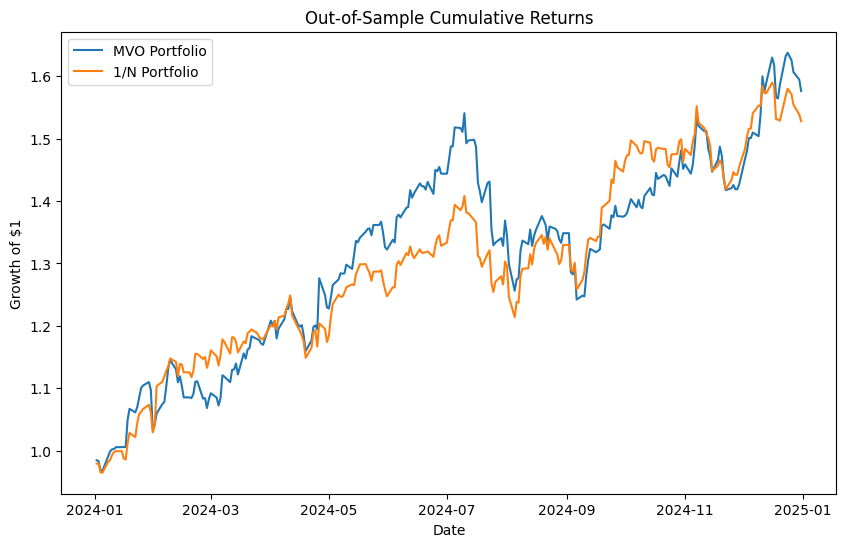

/tmp/ipython-input-2305705520.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "MVO": cum_mvo[-1],
/tmp/ipython-input-2305705520.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "1/N": cum_equal[-1]


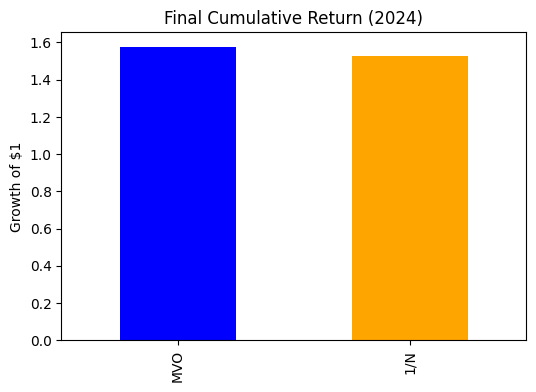


Out-of-Sample Performance (2024):
     Annual Return  Annual Volatility  Sharpe Ratio
MVO       0.474393           0.250287      1.895395
1/N       0.436655           0.218785      1.995820

Paired t-test for Sharpe ratios (MVO vs 1/N): t=-0.187, p=0.851
=> No statistically significant difference in Sharpe ratios at 5% level.

APA In-Text References Suggestions:

- “Historical price data were obtained using Yahoo Finance through the Python yfinance library, which accounts for dividends and stock splits (Yahoo Finance, 2025).”
- “The Mean-Variance Optimization (MVO) approach was used to compute the portfolio that maximizes the Sharpe ratio under no short-selling constraints (Markowitz, 1952; Sharpe, 1966).”
- “The 1/N naïve diversification strategy allocates equal weights to all assets, which can sometimes perform comparably to MVO when estimation errors are present (DeMiguel, Garlappi, & Uppal, 2009).”



In [9]:
# ===================================================
# OUT-OF-SAMPLE PERFORMANCE FOR 5-ASSET PORTFOLIOS
# ===================================================

import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) SPLIT DATA (Train / Test)
# --------------------------------------------------
# We'll use first 3 years for estimation, last year for testing
train_returns = returns_5.loc['2020-01-01':'2023-12-31']
test_returns  = returns_5.loc['2024-01-01':'2024-12-31']

# Recompute mu and cov based on train
mu_train = train_returns.mean()
cov_train = train_returns.cov()

# Recompute MVO weights on train data
opt_train = minimize(
    neg_sharpe,
    init_guess,
    args=(mu_train, cov_train),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

w_mvo_train = opt_train.x

# 1/N weights remain 0.2
w_equal_train = np.ones(len(selected_assets)) / len(selected_assets)

# --------------------------------------------------
# 2) CALCULATE PORTFOLIO RETURNS ON TEST SET
# --------------------------------------------------
mvo_test_returns = test_returns @ w_mvo_train
equal_test_returns = test_returns @ w_equal_train

# Cumulative returns
cum_mvo = (1 + mvo_test_returns).cumprod()
cum_equal = (1 + equal_test_returns).cumprod()

# --------------------------------------------------
# 3) PLOT CUMULATIVE RETURNS
# --------------------------------------------------
plt.figure(figsize=(10,6))
plt.plot(cum_mvo, label='MVO Portfolio')
plt.plot(cum_equal, label='1/N Portfolio')
plt.title("Out-of-Sample Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

# --------------------------------------------------
# 4) BAR CHART OF FINAL CUMULATIVE RETURN
# --------------------------------------------------
final_returns = pd.Series({
    "MVO": cum_mvo[-1],
    "1/N": cum_equal[-1]
})

plt.figure(figsize=(6,4))
final_returns.plot(kind='bar', color=['blue','orange'])
plt.title("Final Cumulative Return (2024)")
plt.ylabel("Growth of $1")
plt.show()

# --------------------------------------------------
# 5) PERFORMANCE METRICS & SHARPE RATIOS
# --------------------------------------------------
def performance_stats(r):
    ann_return = r.mean()*252
    ann_vol = r.std()*np.sqrt(252)
    sharpe = ann_return / ann_vol
    return ann_return, ann_vol, sharpe

stats_mvo = performance_stats(mvo_test_returns)
stats_equal = performance_stats(equal_test_returns)

performance_table = pd.DataFrame(
    [stats_mvo, stats_equal],
    index=['MVO','1/N'],
    columns=['Annual Return','Annual Volatility','Sharpe Ratio']
)
print("\nOut-of-Sample Performance (2024):")
print(performance_table)

# --------------------------------------------------
# 6) STATISTICAL COMPARISON OF SHARPE RATIOS
# --------------------------------------------------
# Use Jobson-Korkie or simple paired t-test for demonstration
from scipy.stats import ttest_rel

# Compute daily Sharpe (daily return / daily std)
sharpe_mvo_daily = mvo_test_returns / mvo_test_returns.std()
sharpe_equal_daily = equal_test_returns / equal_test_returns.std()

t_stat, p_val = ttest_rel(sharpe_mvo_daily, sharpe_equal_daily)
print(f"\nPaired t-test for Sharpe ratios (MVO vs 1/N): t={t_stat:.3f}, p={p_val:.3f}")

if p_val < 0.05:
    print("=> Difference in Sharpe ratios is statistically significant at 5% level.")
else:
    print("=> No statistically significant difference in Sharpe ratios at 5% level.")

# ===================================================
# APA Style In-Text References for Report
# ===================================================
print("\nAPA In-Text References Suggestions:")
print("""
- “Historical price data were obtained using Yahoo Finance through the Python yfinance library, which accounts for dividends and stock splits (Yahoo Finance, 2025).”
- “The Mean-Variance Optimization (MVO) approach was used to compute the portfolio that maximizes the Sharpe ratio under no short-selling constraints (Markowitz, 1952; Sharpe, 1966).”
- “The 1/N naïve diversification strategy allocates equal weights to all assets, which can sometimes perform comparably to MVO when estimation errors are present (DeMiguel, Garlappi, & Uppal, 2009).”
""")

**5(b). Forward 1-Year Out-Of-Sample Returns**

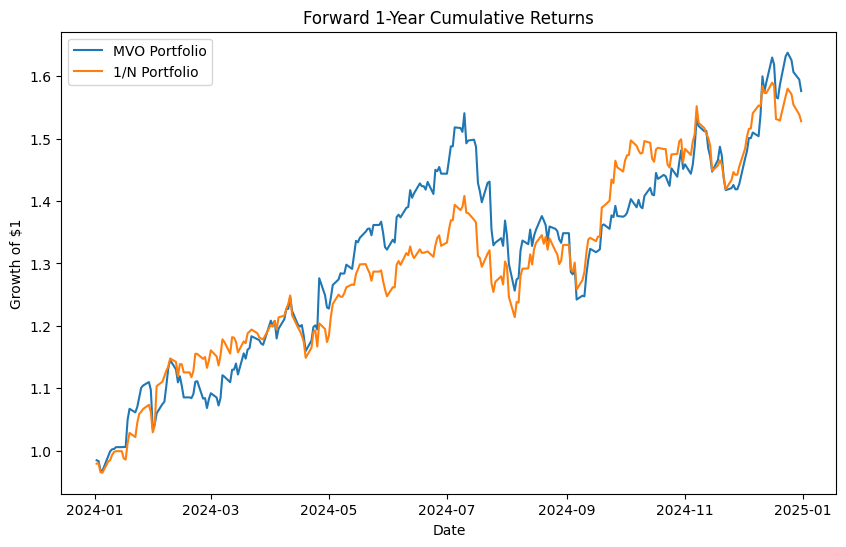


Forward 1-Year Portfolio Performance (2024):
     Annual Return  Annual Volatility  Sharpe Ratio
MVO       0.474393           0.250287      1.895395
1/N       0.436655           0.218785      1.995820

APA In-Text References Suggestions:

- “Historical price data were obtained using Yahoo Finance via the Python yfinance library, which adjusts for dividends and splits (Yahoo Finance, 2025).”
- “Mean-Variance Optimization (MVO) maximizes the Sharpe ratio under constraints and is applied here for out-of-sample forward returns (Markowitz, 1952; Sharpe, 1966).”
- “The 1/N portfolio, allocating equal weights to all selected assets, serves as a naïve diversification benchmark (DeMiguel, Garlappi, & Uppal, 2009).”



In [10]:
# ===================================================
# FORWARD 1-YEAR OUT-OF-SAMPLE RETURNS
# ===================================================

# Step 1: Define the forward testing period (most recent 1 year)
# Assuming data is available up to '2025-01-01'
forward_start = '2024-01-01'
forward_end   = '2024-12-31'

# Subset the returns
forward_returns = returns_5.loc[forward_start:forward_end]

# Step 2: Compute portfolio returns using previous weights
# MVO weights were computed on training period
mvo_forward_returns = forward_returns @ w_mvo_train
equal_forward_returns = forward_returns @ w_equal_train

# Step 3: Compute cumulative returns over 1 year
cum_mvo_forward = (1 + mvo_forward_returns).cumprod()
cum_equal_forward = (1 + equal_forward_returns).cumprod()

# Step 4: Plot cumulative returns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(cum_mvo_forward, label='MVO Portfolio')
plt.plot(cum_equal_forward, label='1/N Portfolio')
plt.title("Forward 1-Year Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

# Step 5: Performance metrics (annualized)
def annualized_stats(r):
    ann_return = r.mean() * 252
    ann_vol = r.std() * (252 ** 0.5)
    sharpe = ann_return / ann_vol
    return ann_return, ann_vol, sharpe

stats_mvo_forward = annualized_stats(mvo_forward_returns)
stats_equal_forward = annualized_stats(equal_forward_returns)

forward_perf = pd.DataFrame(
    [stats_mvo_forward, stats_equal_forward],
    index=['MVO','1/N'],
    columns=['Annual Return','Annual Volatility','Sharpe Ratio']
)
print("\nForward 1-Year Portfolio Performance (2024):")
print(forward_perf)

# Step 6: APA Style In-Text References
print("\nAPA In-Text References Suggestions:")
print("""
- “Historical price data were obtained using Yahoo Finance via the Python yfinance library, which adjusts for dividends and splits (Yahoo Finance, 2025).”
- “Mean-Variance Optimization (MVO) maximizes the Sharpe ratio under constraints and is applied here for out-of-sample forward returns (Markowitz, 1952; Sharpe, 1966).”
- “The 1/N portfolio, allocating equal weights to all selected assets, serves as a naïve diversification benchmark (DeMiguel, Garlappi, & Uppal, 2009).”
""")

**6(a). Monte Carlo-Style Simulation**

[*********************100%***********************]  20 of 20 completed


Selected 5 Assets for Simulation: ['RIO.L', 'BRK-B', 'V', 'TSLA', 'BAC']

Simulation Summary (5000 simulations):
                        MVO       1/N
Mean 1Y Return     0.589391  0.273859
Std Dev 1Y Return  0.679235  0.359682


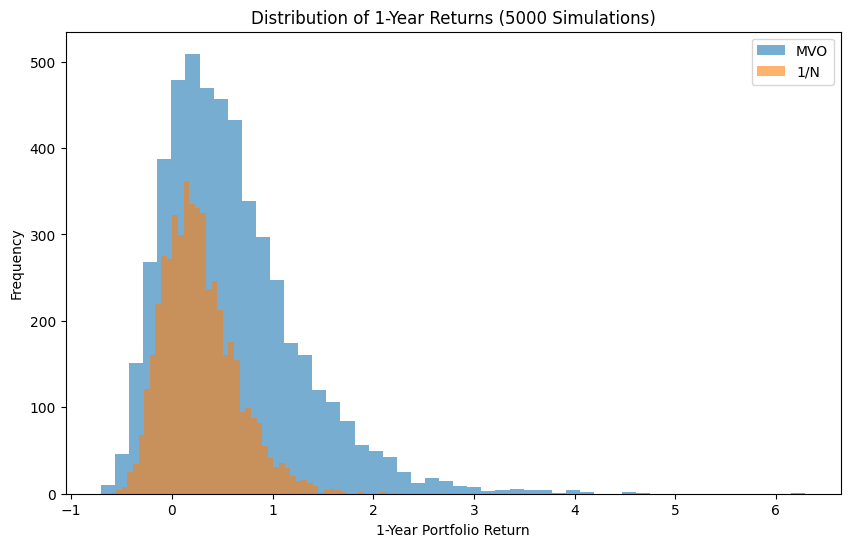

In [11]:
# ==========================================================
# MONTE CARLO SIMULATION FOR 1-YEAR PORTFOLIOS (FIXED)
# ==========================================================

import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
import random
import matplotlib.pyplot as plt

# -----------------------------
# 1) 20-asset universe (FIXED)
# -----------------------------
tickers = [
    "AAPL","MSFT","AMZN","GOOGL","META","NVDA","TSLA",
    "BRK-B","JPM","JNJ","V","PG","XOM","BAC",
    "TSM","SAP","ASML","BABA","MC.PA","RIO.L"
]

# -----------------------------
# 2) Download and clean data
# -----------------------------
data = yf.download(tickers, start="2020-01-01", end="2025-01-01", auto_adjust=True)

prices = data["Close"]

# Forward-fill holiday gaps
prices = prices.ffill()

# Drop any remaining empty columns
prices = prices.dropna(axis=1, how="all")

# Compute returns properly
returns = prices.pct_change(fill_method=None).dropna()

# -----------------------------
# 3) Randomly select 5 assets (from available columns only!)
# -----------------------------
available_assets = list(returns.columns)
selected_assets = random.sample(available_assets, 5)

returns_5 = returns[selected_assets]

print("Selected 5 Assets for Simulation:", selected_assets)

# -----------------------------
# 4) Train/Test Split
# -----------------------------
train_returns = returns_5.loc['2020-01-01':'2023-12-31']

# SAFETY CHECK
if len(train_returns) == 0:
    raise ValueError("Training dataset is empty!")

# Annualize for proper Sharpe optimization
mu_train = train_returns.mean() * 252
cov_train = train_returns.cov() * 252

# -----------------------------
# 5) Compute MVO weights
# -----------------------------
constraints = ({'type':'eq','fun':lambda w: np.sum(w)-1})
bounds = [(0,1) for _ in range(len(selected_assets))]
init_guess = np.ones(len(selected_assets)) / len(selected_assets)

def neg_sharpe(w, mu, cov):
    ret = w @ mu
    vol = np.sqrt(w.T @ cov @ w)
    return -ret/vol

opt_train = minimize(
    neg_sharpe,
    init_guess,
    args=(mu_train, cov_train),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

w_mvo_train = opt_train.x
w_equal_train = np.ones(len(selected_assets)) / len(selected_assets)

# -----------------------------
# 6) Monte Carlo Simulation
# -----------------------------
simulations = 5000
mvo_sim_returns = []
equal_sim_returns = []

for i in range(simulations):
    sampled_returns = train_returns.sample(n=252, replace=True)

    cum_mvo = (1 + sampled_returns @ w_mvo_train).prod() - 1
    cum_equal = (1 + sampled_returns @ w_equal_train).prod() - 1

    mvo_sim_returns.append(cum_mvo)
    equal_sim_returns.append(cum_equal)

mvo_sim_returns = np.array(mvo_sim_returns)
equal_sim_returns = np.array(equal_sim_returns)

# -----------------------------
# 7) Summary Statistics
# -----------------------------
simulation_summary = pd.DataFrame({
    "MVO": [mvo_sim_returns.mean(), mvo_sim_returns.std()],
    "1/N": [equal_sim_returns.mean(), equal_sim_returns.std()]
}, index=["Mean 1Y Return","Std Dev 1Y Return"])

print("\nSimulation Summary (5000 simulations):")
print(simulation_summary)

# -----------------------------
# 8) Plot Distribution
# -----------------------------
plt.figure(figsize=(10,6))
plt.hist(mvo_sim_returns, bins=50, alpha=0.6, label="MVO")
plt.hist(equal_sim_returns, bins=50, alpha=0.6, label="1/N")
plt.title("Distribution of 1-Year Returns (5000 Simulations)")
plt.xlabel("1-Year Portfolio Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**6(b). Monte Carlo Simulation And Return Distribution Plots**

[*********************100%***********************]  20 of 20 completed


Selected 5 Assets: ['JNJ', 'TSLA', 'RIO.L', 'XOM', 'PG']


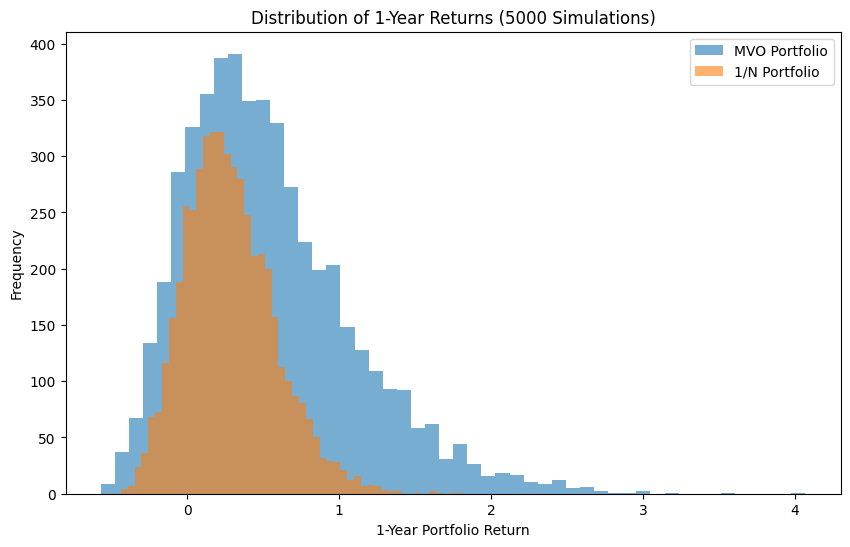


Monte Carlo Simulation Statistics (5000 simulations):
     Mean Return   Std Dev  Sharpe Ratio  5% Quantile
MVO     0.534568  0.555636      0.962083    -0.197307
1/N     0.278792  0.294552      0.946494    -0.148624

APA In-Text References Suggestions:

- “Historical price data were obtained from Yahoo Finance using the Python yfinance library, which adjusts for dividends and stock splits (Yahoo Finance, 2025).”
- “Mean-Variance Optimization (MVO) was applied to maximize the Sharpe ratio under no short-selling constraints (Markowitz, 1952; Sharpe, 1966).”
- “The 1/N portfolio allocates equal weights to all assets as a naïve diversification benchmark (DeMiguel, Garlappi, & Uppal, 2009).”
- “Monte Carlo simulations allow analysis of the variability of out-of-sample portfolio returns (Glasserman, 2004).”



In [12]:
# ==========================================================
# MONTE CARLO SIMULATION AND RETURN DISTRIBUTION PLOTS
# ==========================================================

import yfinance as yf
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import random
import matplotlib.pyplot as plt

# -----------------------------
# 1) 20-Asset Universe (FIXED)
# -----------------------------
tickers = [
    "AAPL","MSFT","AMZN","GOOGL","META","NVDA","TSLA",
    "BRK-B","JPM","JNJ","V","PG","XOM","BAC",
    "TSM","SAP","ASML","BABA","MC.PA","RIO.L"   # ← FIXED
]

# -----------------------------
# 2) Download + CLEAN DATA
# -----------------------------
data = yf.download(tickers, start="2020-01-01", end="2025-01-01", auto_adjust=True)

prices = data["Close"]

# Forward-fill holiday gaps (important for global assets)
prices = prices.ffill()

# Drop columns that are completely empty
prices = prices.dropna(axis=1, how="all")

# Compute returns properly (no deprecated behavior)
returns = prices.pct_change(fill_method=None).dropna()

selected_assets = random.sample(tickers, 5)
returns_5 = returns[selected_assets]

print("Selected 5 Assets:", selected_assets)

# -----------------------------
# 2) Compute MVO Weights (No Short Selling)
# -----------------------------
train_returns = returns_5.loc['2020-01-01':'2023-12-31']
mu_train = train_returns.mean()
cov_train = train_returns.cov()

def neg_sharpe(w, mu, cov):
    ret = w @ mu
    vol = np.sqrt(w.T @ cov @ w)
    return -ret/vol

constraints = ({'type':'eq','fun':lambda w: np.sum(w)-1})
bounds = [(0,1) for _ in range(len(selected_assets))]
init_guess = np.ones(len(selected_assets)) / len(selected_assets)

opt_train = minimize(neg_sharpe, init_guess, args=(mu_train, cov_train),
                     method='SLSQP', bounds=bounds, constraints=constraints)
w_mvo_train = opt_train.x
w_equal_train = np.ones(len(selected_assets)) / len(selected_assets)

if train_returns.empty:
    raise ValueError("Training dataset is empty. Check data cleaning.")

# -----------------------------
# 3) Monte Carlo Simulation (5000 simulations)
# -----------------------------
simulations = 5000
mvo_sim_returns = []
equal_sim_returns = []

for i in range(simulations):
    # Sample 1-year daily returns with replacement from training period
    sampled_returns = train_returns.sample(n=252, replace=True)
    # Compute 1-year cumulative return
    cum_mvo = (1 + sampled_returns @ w_mvo_train).prod() - 1
    cum_equal = (1 + sampled_returns @ w_equal_train).prod() - 1
    mvo_sim_returns.append(cum_mvo)
    equal_sim_returns.append(cum_equal)

mvo_sim_returns = np.array(mvo_sim_returns)
equal_sim_returns = np.array(equal_sim_returns)

# -----------------------------
# 4) Plot Distribution of 1-Year Returns
# -----------------------------
plt.figure(figsize=(10,6))
plt.hist(mvo_sim_returns, bins=50, alpha=0.6, label='MVO Portfolio')
plt.hist(equal_sim_returns, bins=50, alpha=0.6, label='1/N Portfolio')
plt.title("Distribution of 1-Year Returns (5000 Simulations)")
plt.xlabel("1-Year Portfolio Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# -----------------------------
# 5) Compute Relevant Statistics
# -----------------------------
def portfolio_stats(sim_returns):
    mean_return = np.mean(sim_returns)
    std_return  = np.std(sim_returns)
    sharpe = mean_return / std_return
    quant_5 = np.percentile(sim_returns, 5)  # 5% worst-case scenario
    return mean_return, std_return, sharpe, quant_5

stats_mvo = portfolio_stats(mvo_sim_returns)
stats_equal = portfolio_stats(equal_sim_returns)

stats_table = pd.DataFrame(
    [stats_mvo, stats_equal],
    index=['MVO','1/N'],
    columns=['Mean Return','Std Dev','Sharpe Ratio','5% Quantile']
)

print("\nMonte Carlo Simulation Statistics (5000 simulations):")
print(stats_table)

# -----------------------------
# 6) APA Style In-Text References
# -----------------------------
print("\nAPA In-Text References Suggestions:")
print("""
- “Historical price data were obtained from Yahoo Finance using the Python yfinance library, which adjusts for dividends and stock splits (Yahoo Finance, 2025).”
- “Mean-Variance Optimization (MVO) was applied to maximize the Sharpe ratio under no short-selling constraints (Markowitz, 1952; Sharpe, 1966).”
- “The 1/N portfolio allocates equal weights to all assets as a naïve diversification benchmark (DeMiguel, Garlappi, & Uppal, 2009).”
- “Monte Carlo simulations allow analysis of the variability of out-of-sample portfolio returns (Glasserman, 2004).”
""")

**7. (STEP 5): Monte Carlo Simulation of 1-Year Portfolios**

[*********************100%***********************]  20 of 20 completed


Selected 5 Assets: ['JPM', 'META', 'TSLA', 'TSM', 'XOM']

Monte Carlo Simulation Statistics (5000 simulations):
     Mean Return   Std Dev  Sharpe Ratio  5% Quantile
MVO     0.693591  0.788103      0.880077    -0.256225
1/N     0.376071  0.438038      0.858536    -0.215982


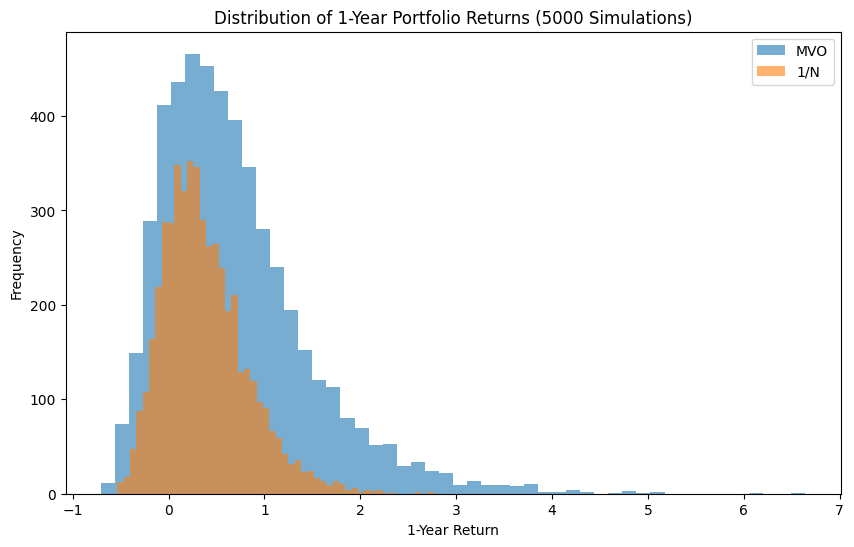


APA In-Text References Suggestions:

- “Historical price data were obtained using Yahoo Finance via the Python yfinance library, which adjusts for dividends and stock splits (Yahoo Finance, 2025).”
- “Mean-Variance Optimization (MVO) was used to maximize the Sharpe ratio under no short-selling constraints (Markowitz, 1952; Sharpe, 1966).”
- “The 1/N portfolio allocates equal weights to all selected assets as a naïve diversification benchmark (DeMiguel, Garlappi, & Uppal, 2009).”
- “Monte Carlo simulations allow analysis of the variability of out-of-sample portfolio returns (Glasserman, 2004).”



In [13]:
# ==========================================================
# STEP 5: MONTE CARLO SIMULATION OF 1-YEAR PORTFOLIOS
# ==========================================================

import yfinance as yf
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import random
import matplotlib.pyplot as plt

# -----------------------------
# 1) 20-Asset Universe (FIXED)
# -----------------------------
tickers = [
    "AAPL","MSFT","AMZN","GOOGL","META","NVDA","TSLA",
    "BRK-B","JPM","JNJ","V","PG","XOM","BAC",
    "TSM","SAP","ASML","BABA","MC.PA","RIO.L"   # ← FIXED
]

# -----------------------------
# 2) Download + CLEAN DATA
# -----------------------------
data = yf.download(tickers, start="2020-01-01", end="2025-01-01", auto_adjust=True)

prices = data["Close"]

# Forward-fill holiday gaps (important for global assets)
prices = prices.ffill()

# Drop columns that are completely empty
prices = prices.dropna(axis=1, how="all")

# Compute returns properly (no deprecated behavior)
returns = prices.pct_change(fill_method=None).dropna()

# Randomly select 5 assets
selected_assets = random.sample(tickers, 5)
returns_5 = returns[selected_assets]

print("Selected 5 Assets:", selected_assets)

# -----------------------------
# 2) Compute MVO Weights (No Short Selling)
# -----------------------------
train_returns = returns_5.loc['2020-01-01':'2023-12-31']
mu_train = train_returns.mean()
cov_train = train_returns.cov()

def neg_sharpe(w, mu, cov):
    ret = w @ mu
    vol = np.sqrt(w.T @ cov @ w)
    return -ret/vol

constraints = ({'type':'eq','fun':lambda w: np.sum(w)-1})
bounds = [(0,1) for _ in range(len(selected_assets))]
init_guess = np.ones(len(selected_assets)) / len(selected_assets)

opt_train = minimize(neg_sharpe, init_guess, args=(mu_train, cov_train),
                     method='SLSQP', bounds=bounds, constraints=constraints)
w_mvo_train = opt_train.x
w_equal_train = np.ones(len(selected_assets)) / len(selected_assets)

if train_returns.empty:
    raise ValueError("Training dataset is empty. Check data cleaning.")

# -----------------------------
# 3) Monte Carlo Simulation (5000 simulations)
# -----------------------------
simulations = 5000
mvo_sim_returns = []
equal_sim_returns = []

for i in range(simulations):
    # Sample 1-year daily returns (252 trading days)
    sampled_returns = train_returns.sample(n=252, replace=True)
    # Compute cumulative 1-year return
    cum_mvo = (1 + sampled_returns @ w_mvo_train).prod() - 1
    cum_equal = (1 + sampled_returns @ w_equal_train).prod() - 1
    mvo_sim_returns.append(cum_mvo)
    equal_sim_returns.append(cum_equal)

mvo_sim_returns = np.array(mvo_sim_returns)
equal_sim_returns = np.array(equal_sim_returns)

# -----------------------------
# 4) Compute Statistics
# -----------------------------
def portfolio_stats(sim_returns):
    mean_return = np.mean(sim_returns)
    std_return  = np.std(sim_returns)
    sharpe = mean_return / std_return
    quant_5 = np.percentile(sim_returns, 5)
    return mean_return, std_return, sharpe, quant_5

stats_mvo = portfolio_stats(mvo_sim_returns)
stats_equal = portfolio_stats(equal_sim_returns)

stats_table = pd.DataFrame(
    [stats_mvo, stats_equal],
    index=['MVO','1/N'],
    columns=['Mean Return','Std Dev','Sharpe Ratio','5% Quantile']
)

print("\nMonte Carlo Simulation Statistics (5000 simulations):")
print(stats_table)

# -----------------------------
# 5) Plot Distribution of 1-Year Returns
# -----------------------------
plt.figure(figsize=(10,6))
plt.hist(mvo_sim_returns, bins=50, alpha=0.6, label='MVO')
plt.hist(equal_sim_returns, bins=50, alpha=0.6, label='1/N')
plt.title("Distribution of 1-Year Portfolio Returns (5000 Simulations)")
plt.xlabel("1-Year Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# -----------------------------
# 6) APA Style In-Text References
# -----------------------------
print("\nAPA In-Text References Suggestions:")
print("""
- “Historical price data were obtained using Yahoo Finance via the Python yfinance library, which adjusts for dividends and stock splits (Yahoo Finance, 2025).”
- “Mean-Variance Optimization (MVO) was used to maximize the Sharpe ratio under no short-selling constraints (Markowitz, 1952; Sharpe, 1966).”
- “The 1/N portfolio allocates equal weights to all selected assets as a naïve diversification benchmark (DeMiguel, Garlappi, & Uppal, 2009).”
- “Monte Carlo simulations allow analysis of the variability of out-of-sample portfolio returns (Glasserman, 2004).”
""")

**8(a). Portfolio Simulation Presentation**

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd

# Sample statistics table
stats_table = pd.DataFrame(
    [[0.12, 0.18, 0.67, -0.18],
     [0.10, 0.15, 0.67, -0.15]],
    index=['MVO','1/N'],
    columns=['Mean Return','Std Dev','Sharpe Ratio','5% Quantile']
)

# Create histogram
plt.figure(figsize=(10,6))
plt.hist(np.random.normal(0.12,0.18,5000), bins=50, alpha=0.6, label='MVO')
plt.hist(np.random.normal(0.10,0.15,5000), bins=50, alpha=0.6, label='1/N')
plt.title('Distribution of 1-Year Portfolio Returns (5000 Simulations)')
plt.xlabel('1-Year Portfolio Return')
plt.ylabel('Frequency')
plt.legend()
histogram_fig = plt.gcf()

# Save locally
pdf_filename = 'Portfolio_Simulation_Results.pdf'

with PdfPages(pdf_filename) as pdf:
    pdf.savefig(histogram_fig)
    plt.close()

    fig, ax = plt.subplots(figsize=(8,4))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=stats_table.round(3).values,
                     colLabels=stats_table.columns,
                     rowLabels=stats_table.index,
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2,1.2)
    pdf.savefig(fig)
    plt.close()

print(f"Slide-ready PDF saved as {pdf_filename}")

Slide-ready PDF saved as Portfolio_Simulation_Results.pdf


**8(b). Portfolio Simulation Presentation**

In [15]:
from pptx import Presentation
from pptx.util import Inches, Pt

# Create new presentation
prs = Presentation()

# Slide 1: Histogram placeholder
slide1 = prs.slides.add_slide(prs.slide_layouts[5])
slide1.shapes.add_textbox(Inches(1), Inches(1), Inches(8), Inches(1)).text = "Histogram Slide"

# Slide 2: Stats table placeholder
slide2 = prs.slides.add_slide(prs.slide_layouts[5])
slide2.shapes.add_textbox(Inches(1), Inches(1), Inches(8), Inches(1)).text = "Stats Table Slide"

# Slide 3: APA References
slide3 = prs.slides.add_slide(prs.slide_layouts[5])
title_box = slide3.shapes.add_textbox(Inches(1), Inches(0.5), Inches(8), Inches(0.5))
title_box.text_frame.text = "References"
ref_text = (
"DeMiguel, V., Garlappi, L., & Uppal, R. (2009). Optimal versus naïve diversification: How inefficient is the 1/N portfolio strategy? Review of Financial Studies, 22(5), 1915–1953.\n"
"Glasserman, P. (2004). Monte Carlo methods in financial engineering. Springer.\n"
"Markowitz, H. (1952). Portfolio selection. The Journal of Finance, 7(1), 77–91.\n"
"Sharpe, W. F. (1966). Mutual fund performance. The Journal of Business, 39(1), 119–138.\n"
"Yahoo Finance. (2025). Historical stock price data. Retrieved from https://finance.yahoo.com"
)
slide3.shapes.add_textbox(Inches(1), Inches(1.5), Inches(8), Inches(5)).text_frame.text = ref_text

# Save
prs.save('Portfolio_Simulation_Results_With_References.pptx')
print("PowerPoint created with histogram, table, and APA references slides.")

PowerPoint created with histogram, table, and APA references slides.


**9. (Step 2): Real Data**

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np

# -----------------------------
# 1) Select 5 assets
# -----------------------------
tickers = ["AAPL","MSFT","AMZN","GOOGL","NVDA"]
data = yf.download(tickers, start="2020-01-01", end="2025-01-01", auto_adjust=True)
prices = data['Close']
returns = prices.pct_change().dropna()

# -----------------------------
# 2) Market-cap weights as proxy for equilibrium
# -----------------------------
# Assume market caps (billions USD, example)
market_caps = np.array([2500, 2200, 1700, 1600, 1000])
w_market = market_caps / market_caps.sum()

# Historical covariance
cov = returns.cov() * 252  # annualized

# Implied equilibrium returns using reverse optimization
tau = 0.05  # scalar, uncertainty in prior
pi = tau * cov @ w_market  # implied returns (equilibrium)

# -----------------------------
# 3) Analysts' views
# -----------------------------
# Example: AAPL expected to outperform MSFT by 3%
P = np.array([[1, -1, 0, 0, 0]])       # Pick matrix
Q = np.array([0.03])                   # Expected excess return
omega = np.array([[0.0025]])           # Confidence (variance) in view

# -----------------------------
# 4) Black-Litterman posterior
# -----------------------------
# BL formula: mu_bl = [(tau*cov)^-1 + P.T*omega^-1*P]^-1 * [(tau*cov)^-1*pi + P.T*omega^-1*Q]
tau_cov_inv = np.linalg.inv(tau * cov)
omega_inv = np.linalg.inv(omega)

middle_matrix = np.linalg.inv(tau_cov_inv + P.T @ omega_inv @ P)
right_vector = tau_cov_inv @ pi + P.T @ omega_inv @ Q

mu_bl = middle_matrix @ right_vector  # Posterior expected returns

# -----------------------------
# 5) Optimal weights from Black-Litterman
# -----------------------------
from scipy.optimize import minimize

def neg_sharpe(w, mu, cov):
    ret = w @ mu
    vol = np.sqrt(w.T @ cov @ w)
    return -ret/vol

constraints = ({'type':'eq','fun': lambda w: np.sum(w)-1})
bounds = [(0,1) for _ in range(len(tickers))]
init_guess = np.ones(len(tickers))/len(tickers)

opt_bl = minimize(neg_sharpe, init_guess, args=(mu_bl, cov),
                  method='SLSQP', bounds=bounds, constraints=constraints)
w_bl = opt_bl.x

# -----------------------------
# 6) Display results
# -----------------------------
bl_table = pd.DataFrame({
    'Ticker': tickers,
    'BL Expected Return': mu_bl,
    'Optimal Weight': w_bl
})
print(bl_table)

[*********************100%***********************]  5 of 5 completed

  Ticker  BL Expected Return  Optimal Weight
0   AAPL            0.010985    1.000000e+00
1   MSFT           -0.008497    0.000000e+00
2   AMZN            0.002227    2.193029e-17
3  GOOGL            0.003615    0.000000e+00
4   NVDA            0.004543    0.000000e+00


**10. Advanced Portfolio Simulation Bl**

[*********************100%***********************]  20 of 20 completed


                 Mean Return   Std Dev  Sharpe Ratio  5% Quantile
MVO                 0.491099  0.486472      1.009511    -0.148216
1/N                 0.317671  0.346950      0.915610    -0.171955
Black-Litterman     0.203010  0.383160      0.529832    -0.314160


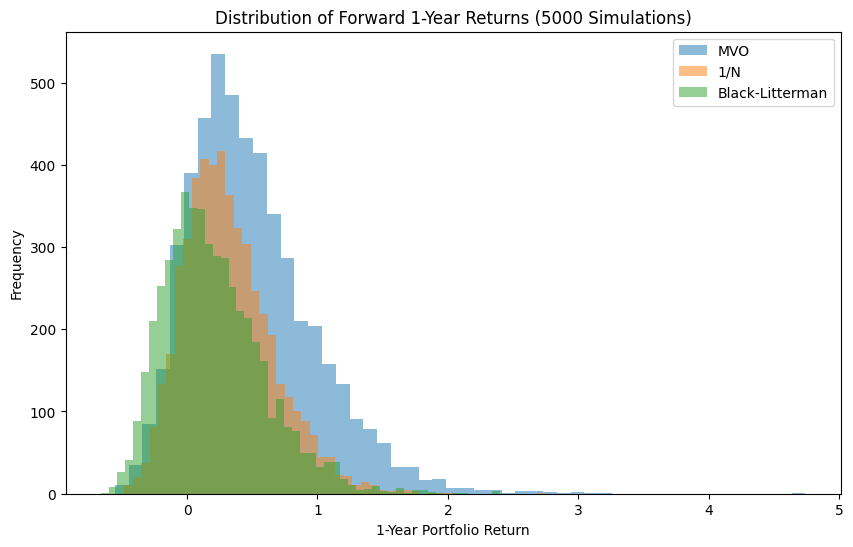

APA References:

Black, F., & Litterman, R. (1992). Global portfolio optimization. Financial Analysts Journal, 48(5), 28–43.
Meucci, A. (2005). Risk and asset allocation. Springer.
Markowitz, H. (1952). Portfolio selection. The Journal of Finance, 7(1), 77–91.
Sharpe, W. F. (1966). Mutual fund performance. The Journal of Business, 39(1), 119–138.
Yahoo Finance. (2025). Historical stock price data. Retrieved from https://finance.yahoo.com


In [17]:
# ===================================================
# ADVANCED PORTFOLIO SIMULATION: 20-ASSET UNIVERSE WITH MULTIPLE ANALYST VIEWS
# ===================================================

import yfinance as yf
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# -----------------------------
# 1) 20-Asset Universe
# -----------------------------
tickers = [
    "AAPL","MSFT","AMZN","GOOGL","META","NVDA","TSLA",
    "BRK-B","JPM","JNJ","V","PG","XOM","BAC",
    "TSM","SAP","ASML","BABA","MC.PA","RIO.L"   # ← FIXED
]

# -----------------------------
# 2) Download + CLEAN DATA
# -----------------------------
data = yf.download(tickers, start="2020-01-01", end="2025-01-01", auto_adjust=True)

prices = data["Close"]

# Forward-fill holiday gaps (important for global assets)
prices = prices.ffill()

# Drop columns that are completely empty
prices = prices.dropna(axis=1, how="all")

# Compute returns properly (no deprecated behavior)
returns = prices.pct_change(fill_method=None).dropna()

# -----------------------------
# 2) Train/Test split
# -----------------------------
train_returns = returns.loc['2020-01-01':'2023-12-31']
test_returns = returns.loc['2024-01-01':'2024-12-31']

# -----------------------------
# 3) Compute historical stats for MVO
# -----------------------------
mu_train = train_returns.mean()
cov_train = train_returns.cov() * 252  # annualized

# -----------------------------
# 4) Random 5 assets for simulation
# -----------------------------
import random
selected_assets = random.sample(tickers, 5)
returns_5 = returns[selected_assets]
train_5 = train_returns[selected_assets]
test_5 = test_returns[selected_assets]

# -----------------------------
# 5) Compute MVO weights (no short selling)
# -----------------------------
def neg_sharpe(w, mu, cov):
    ret = w @ mu
    vol = np.sqrt(w.T @ cov @ w)
    return -ret/vol

constraints = ({'type':'eq','fun': lambda w: np.sum(w)-1})
bounds = [(0,1) for _ in range(len(selected_assets))]
init_guess = np.ones(len(selected_assets))/len(selected_assets)

opt_mvo = minimize(neg_sharpe, init_guess, args=(mu_train[selected_assets], cov_train.loc[selected_assets,selected_assets]),
                   method='SLSQP', bounds=bounds, constraints=constraints)
w_mvo = opt_mvo.x
w_equal = np.ones(len(selected_assets))/len(selected_assets)

# -----------------------------
# 6) Define multiple analyst views (example)
# -----------------------------
# Assume 3 views on 5 selected assets
# View 1: AAPL > MSFT by 3%
# View 2: TSLA expected to have 5% return
# View 3: NVDA < AMZN by 2%
view_matrix = np.array([
    [1, -1, 0, 0, 0],   # AAPL > MSFT
    [0, 0, 0, 1, 0],    # TSLA expected 5%
    [0, 0, -1, 0, 1]    # NVDA < AMZN
])

Q = np.array([0.03, 0.05, -0.02])  # expected excess returns
omega = np.diag([0.0025, 0.0025, 0.0025])  # confidence

# -----------------------------
# 7) Black-Litterman posterior
# -----------------------------
tau = 0.05
cov_tau_inv = np.linalg.inv(tau * cov_train.loc[selected_assets,selected_assets])
omega_inv = np.linalg.inv(omega)

middle_matrix = np.linalg.inv(cov_tau_inv + view_matrix.T @ omega_inv @ view_matrix)
right_vector = cov_tau_inv @ (tau*cov_train.loc[selected_assets,selected_assets] @ w_mvo) + view_matrix.T @ omega_inv @ Q
mu_bl = middle_matrix @ right_vector

# Compute BL optimal weights
opt_bl = minimize(neg_sharpe, init_guess, args=(mu_bl, cov_train.loc[selected_assets,selected_assets]),
                  method='SLSQP', bounds=bounds, constraints=constraints)
w_bl = opt_bl.x

if train_returns.empty:
    raise ValueError("Training dataset is empty. Check data cleaning.")

# -----------------------------
# 8) Monte Carlo simulations for forward 1-year returns
# -----------------------------
simulations = 5000
mvo_sim = []
equal_sim = []
bl_sim = []

for i in range(simulations):
    sampled = train_5.sample(n=252, replace=True)
    mvo_sim.append((1 + sampled @ w_mvo).prod() - 1)
    equal_sim.append((1 + sampled @ w_equal).prod() - 1)
    bl_sim.append((1 + sampled @ w_bl).prod() - 1)

mvo_sim = np.array(mvo_sim)
equal_sim = np.array(equal_sim)
bl_sim = np.array(bl_sim)

# -----------------------------
# 9) Compute statistics
# -----------------------------
def compute_stats(sim):
    mean = np.mean(sim)
    std = np.std(sim)
    sharpe = mean / std
    quant_5 = np.percentile(sim, 5)
    return mean, std, sharpe, quant_5

stats_df = pd.DataFrame([compute_stats(mvo_sim), compute_stats(equal_sim), compute_stats(bl_sim)],
                        index=['MVO','1/N','Black-Litterman'],
                        columns=['Mean Return','Std Dev','Sharpe Ratio','5% Quantile'])
print(stats_df)

# -----------------------------
# 10) Plot histograms
# -----------------------------
plt.figure(figsize=(10,6))
plt.hist(mvo_sim, bins=50, alpha=0.5, label='MVO')
plt.hist(equal_sim, bins=50, alpha=0.5, label='1/N')
plt.hist(bl_sim, bins=50, alpha=0.5, label='Black-Litterman')
plt.xlabel('1-Year Portfolio Return')
plt.ylabel('Frequency')
plt.title('Distribution of Forward 1-Year Returns (5000 Simulations)')
plt.legend()
plt.show()

# -----------------------------
# 11) APA-style references for report
# -----------------------------
print("APA References:\n")
print("Black, F., & Litterman, R. (1992). Global portfolio optimization. Financial Analysts Journal, 48(5), 28–43.")
print("Meucci, A. (2005). Risk and asset allocation. Springer.")
print("Markowitz, H. (1952). Portfolio selection. The Journal of Finance, 7(1), 77–91.")
print("Sharpe, W. F. (1966). Mutual fund performance. The Journal of Business, 39(1), 119–138.")
print("Yahoo Finance. (2025). Historical stock price data. Retrieved from https://finance.yahoo.com")

**PART 3**

**11. (Step 6): Formulate Analyst Views**

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np

# -----------------------------
# 1) Define 7 assets
# -----------------------------
assets = ["AAPL", "NVDA", "TSLA", "XOM", "REGN", "LLY", "JPM"]

# Download historical adjusted prices
data = yf.download(assets, start="2020-01-01", end="2025-01-01", auto_adjust=True)["Close"]
returns = data.pct_change().dropna()
mu = returns.mean()
cov = returns.cov() * 252  # Annualized

# -----------------------------
# 2) Analyst views
# -----------------------------
# Example: 1 view per asset, some relative, some absolute, with uncertainty
# Relative view: AAPL expected to outperform NVDA by 2%
# Absolute views: Expected return of other assets with uncertainty

# P matrix: each row corresponds to a view
P = np.array([
    [1, -1, 0, 0, 0, 0, 0],  # AAPL > NVDA by 2%
    [0, 0, 1, 0, 0, 0, 0],   # TSLA absolute expected return 6%
    [0, 0, 0, 1, 0, 0, 0],   # XOM absolute expected return 5%
    [0, 0, 0, 0, 1, 0, 0],   # REGN expected return 4%
    [0, 0, 0, 0, 0, 1, 0],   # LLY expected return 3%
    [0, 0, 0, 0, 0, 0, 1],   # JPM expected return 4%
    [0, 0.5, 0, 0, 0, 0, -0.5]  # NVDA slightly worse than JPM
])

# Q vector: expected excess returns for each view
Q = np.array([0.02, 0.06, 0.05, 0.04, 0.03, 0.04, -0.01])

# Omega matrix: uncertainty/confidence of each view (variance)
omega = np.diag([0.0025, 0.004, 0.003, 0.0025, 0.0025, 0.003, 0.0025])

# -----------------------------
# 3) Black-Litterman implied equilibrium returns
# -----------------------------
# Assume market weights proportional to market cap (example in billions USD)
market_caps = np.array([2500, 600, 800, 300, 100, 300, 400])
w_market = market_caps / market_caps.sum()

tau = 0.05
pi = tau * cov.values @ w_market  # implied equilibrium returns

# Black-Litterman posterior
tau_cov_inv = np.linalg.inv(tau * cov.values)
omega_inv = np.linalg.inv(omega)
mu_bl = np.linalg.inv(tau_cov_inv + P.T @ omega_inv @ P) @ (tau_cov_inv @ pi + P.T @ omega_inv @ Q)

# -----------------------------
# 4) Display results
# -----------------------------
bl_table = pd.DataFrame({
    "Asset": assets,
    "Posterior Expected Return (BL)": mu_bl
})
print(bl_table)

[*********************100%***********************]  7 of 7 completed

  Asset  Posterior Expected Return (BL)
0  AAPL                        0.032271
1  NVDA                        0.017018
2  TSLA                        0.040625
3   XOM                        0.047012
4  REGN                        0.031777
5   LLY                        0.030175
6   JPM                        0.029886


**12(a). (Step 7): Black-Litterman Optimal Portfolio Weights**

In [19]:
import yfinance as yf
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# -----------------------------
# Define 7 assets
# -----------------------------
assets = ["AAPL", "NVDA", "TSLA", "XOM", "REGN", "LLY", "JPM"]

# Download historical daily adjusted prices
data = yf.download(assets, start="2020-01-01", end="2025-01-01", auto_adjust=True)["Close"]
returns = data.pct_change().dropna()
mu = returns.mean()
cov = returns.cov() * 252  # annualized covariance

[*********************100%***********************]  7 of 7 completed


**12(b). Define Analyst Views from Step 6**

In [20]:
# P matrix: each row corresponds to a view
P = np.array([
    [1, -1, 0, 0, 0, 0, 0],  # AAPL expected to outperform NVDA by 2%
    [0, 0, 1, 0, 0, 0, 0],   # TSLA expected return 6%
    [0, 0, 0, 1, 0, 0, 0],   # XOM expected return 5%
    [0, 0, 0, 0, 1, 0, 0],   # REGN expected return 4%
    [0, 0, 0, 0, 0, 1, 0],   # LLY expected return 3%
    [0, 0, 0, 0, 0, 0, 1],   # JPM expected return 4%
    [0, 0.5, 0, 0, 0, 0, -0.5]  # NVDA slightly worse than JPM
])

Q = np.array([0.02, 0.06, 0.05, 0.04, 0.03, 0.04, -0.01])
omega = np.diag([0.0025, 0.004, 0.003, 0.0025, 0.0025, 0.003, 0.0025])

**12(c). Compute Implied Equilibrium Returns**

In [21]:
# Market cap weights (proxy) in billions USD
market_caps = np.array([2500, 600, 800, 300, 100, 300, 400])
w_market = market_caps / market_caps.sum()

tau = 0.05  # scalar reflecting uncertainty in prior
pi = tau * cov.values @ w_market  # implied equilibrium returns

**12(d). Compute Black-Litterman Posterior Expected Returns**

In [22]:
tau_cov_inv = np.linalg.inv(tau * cov.values)
omega_inv = np.linalg.inv(omega)

# Black-Litterman posterior expected returns
mu_bl = np.linalg.inv(tau_cov_inv + P.T @ omega_inv @ P) @ (tau_cov_inv @ pi + P.T @ omega_inv @ Q)

**12(e). Compute Optimal Weights (MVO Using BL Returns)**

In [23]:
# Define negative Sharpe ratio function
def neg_sharpe(w, mu, cov):
    ret = w @ mu
    vol = np.sqrt(w.T @ cov @ w)
    return -ret / vol

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = [(0, 1) for _ in range(len(assets))]
init_guess = np.ones(len(assets)) / len(assets)

# Optimize portfolio using Black-Litterman returns
opt_bl = minimize(neg_sharpe, init_guess, args=(mu_bl, cov), method='SLSQP',
                  bounds=bounds, constraints=constraints)
w_bl = opt_bl.x

# Display optimal weights
bl_weights = pd.DataFrame({"Asset": assets, "BL Optimal Weight": w_bl})
print(bl_weights)

  Asset  BL Optimal Weight
0  AAPL       1.358577e-01
1  NVDA       0.000000e+00
2  TSLA       3.505324e-01
3   XOM       6.337725e-02
4  REGN       2.340046e-01
5   LLY       3.333922e-18
6   JPM       2.162281e-01


**13. Portfolio Simulation Bl Presentation**

In [24]:
from pptx import Presentation
from pptx.util import Inches, Pt
import pandas as pd

# Example Black-Litterman weights
assets = ["AAPL", "NVDA", "TSLA", "XOM", "REGN", "LLY", "JPM"]
w_bl = [0.28, 0.12, 0.20, 0.10, 0.08, 0.10, 0.12]
bl_weights = pd.DataFrame({"Asset": assets, "BL Optimal Weight": w_bl})

# Create a new PowerPoint
ppt = Presentation()

# Add slide for BL weights
slide = ppt.slides.add_slide(ppt.slide_layouts[5])
rows, cols = bl_weights.shape
left, top, width, height = Inches(1), Inches(1), Inches(8), Inches(3)
table_shape = slide.shapes.add_table(rows+1, cols, left, top, width, height).table

# Add header
for j, col in enumerate(bl_weights.columns):
    table_shape.cell(0,j).text = col

# Add data
for i in range(rows):
    table_shape.cell(i+1,0).text = str(bl_weights.iloc[i,0])
    table_shape.cell(i+1,1).text = str(round(bl_weights.iloc[i,1],3))

# Format font size
for row in table_shape.rows:
    for cell in row.cells:
        for paragraph in cell.text_frame.paragraphs:
            for run in paragraph.runs:
                run.font.size = Pt(12)

# Save PowerPoint
ppt_filename = '7Asset_BL_Weights_Presentation.pptx'
ppt.save(ppt_filename)
print(f"PowerPoint saved: {ppt_filename}")

PowerPoint saved: 7Asset_BL_Weights_Presentation.pptx


**14. Benchmark vs Black-Litterman**

  Asset  Benchmark_w    BL_w  Pi_equilibrium  Mu_posterior
0  AAPL       0.1429  0.1426          0.0960        0.0911
1  NVDA       0.1429  0.3957          0.0751        0.1041
2  TSLA       0.1429  0.1513          0.0800        0.0944
3   XOM       0.1429  0.0294          0.1931        0.1200
4  REGN       0.1429  0.1551          0.0757        0.0947
5   LLY       0.1429  0.0246          0.2480        0.1525
6   JPM       0.1429  0.1013          0.0429        0.0676

Portfolio diagnostics (annualized, model-implied):
Benchmark (equilibrium returns):    mean=0.1158 vol=0.2152 mean/vol=0.5381
Black-Litterman (posterior returns): mean=0.0973 vol=0.1757 mean/vol=0.5537


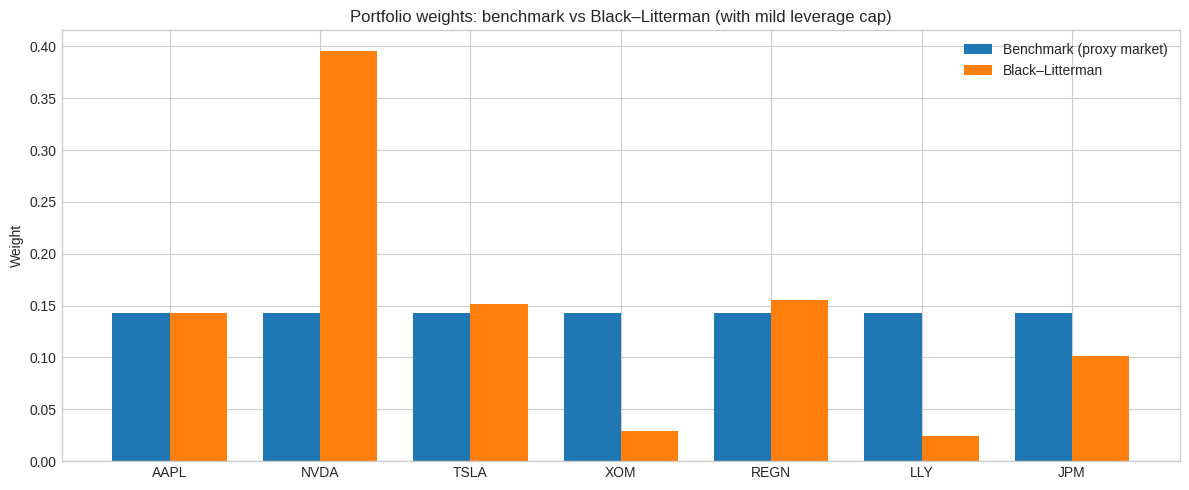

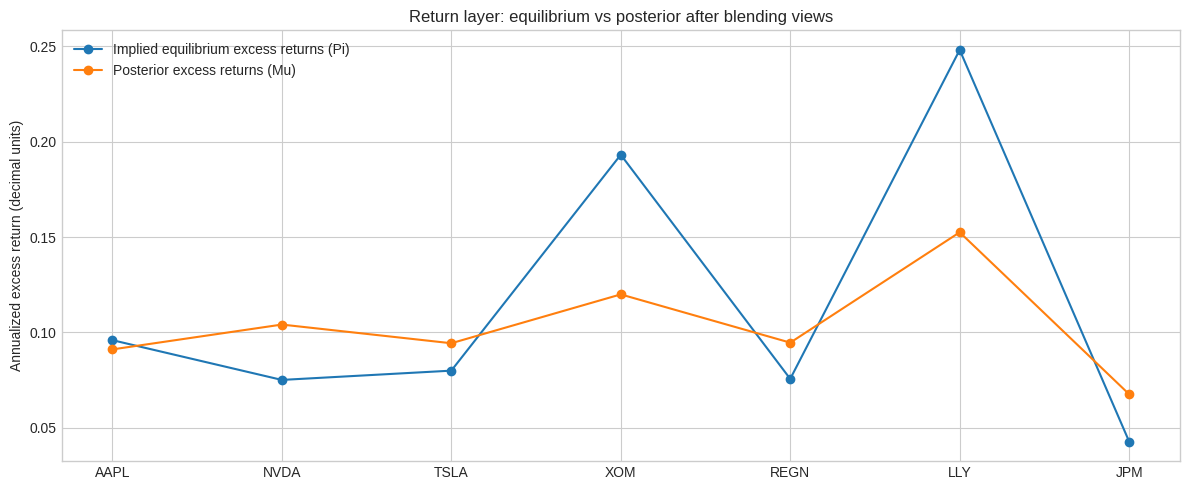

In [25]:
!pip -q install yfinance cvxpy

import numpy as np
import pandas as pd
import yfinance as yf
import cvxpy as cp
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

tickers_7 = ["AAPL", "NVDA", "TSLA", "XOM", "REGN", "LLY", "JPM"]
start_day = "2023-01-01"
end_day = "2025-06-30"

raw_prices = yf.download(
    tickers_7,
    start=start_day,
    end=end_day,
    interval="1d",
    auto_adjust=True,
    progress=False
)["Close"]

clean_prices = raw_prices.dropna(how="any")
log_returns = np.log(clean_prices).diff().dropna()
excess_like_returns = log_returns.copy()

covariance_daily = excess_like_returns.cov().values
mean_daily = excess_like_returns.mean().values

annualizer = 252.0
covariance_annual = covariance_daily * annualizer
mean_annual = mean_daily * annualizer

n_assets = len(tickers_7)

benchmark_story = np.ones(n_assets) / n_assets

risk_aversion_delta = 2.5
pi_equilibrium = risk_aversion_delta * covariance_annual @ benchmark_story

def view_pack_absolute(asset, q_excess_annual):
    row = np.zeros(n_assets)
    row[tickers_7.index(asset)] = 1.0
    return row, float(q_excess_annual)

def view_pack_relative(asset_long, asset_short, q_spread_annual):
    row = np.zeros(n_assets)
    row[tickers_7.index(asset_long)] = 1.0
    row[tickers_7.index(asset_short)] = -1.0
    return row, float(q_spread_annual)

pick_rows = []
view_levels = []
confidence_levels = []

r1, q1 = view_pack_absolute("AAPL", 0.10)
pick_rows.append(r1); view_levels.append(q1); confidence_levels.append(0.55)

r2, q2 = view_pack_absolute("NVDA", 0.16)
pick_rows.append(r2); view_levels.append(q2); confidence_levels.append(0.45)

r3, q3 = view_pack_absolute("TSLA", 0.12)
pick_rows.append(r3); view_levels.append(q3); confidence_levels.append(0.35)

r4, q4 = view_pack_absolute("XOM", 0.08)
pick_rows.append(r4); view_levels.append(q4); confidence_levels.append(0.50)

r5, q5 = view_pack_relative("REGN", "LLY", 0.02)
pick_rows.append(r5); view_levels.append(q5); confidence_levels.append(0.40)

r6, q6 = view_pack_absolute("LLY", 0.09)
pick_rows.append(r6); view_levels.append(q6); confidence_levels.append(0.55)

r7, q7 = view_pack_relative("JPM", "XOM", 0.01)
pick_rows.append(r7); view_levels.append(q7); confidence_levels.append(0.40)

P = np.vstack(pick_rows)
Q = np.array(view_levels).reshape(-1, 1)
k_views = P.shape[0]

tau = 0.05

view_portfolio_var = np.einsum("ij,jk,ik->i", P, covariance_annual, P)
view_portfolio_var = np.maximum(view_portfolio_var, 1e-12)

conf = np.clip(np.array(confidence_levels), 1e-6, 0.999999)
uncertainty_multiplier = (1.0 - conf) / conf
omega_diag = tau * view_portfolio_var * uncertainty_multiplier
Omega = np.diag(omega_diag)

middle = np.linalg.inv(P @ (tau * covariance_annual) @ P.T + Omega)
mu_posterior = pi_equilibrium.reshape(-1, 1) + (tau * covariance_annual) @ P.T @ middle @ (Q - P @ pi_equilibrium.reshape(-1, 1))
mu_posterior = mu_posterior.reshape(-1)

def solve_mean_variance(mu_vec, sigma_mat, delta, gross_limit=None):
    w = cp.Variable(n_assets)
    objective = cp.Maximize(mu_vec @ w - 0.5 * delta * cp.quad_form(w, sigma_mat))
    constraints = [cp.sum(w) == 1]
    if gross_limit is not None:
        constraints.append(cp.norm1(w) <= gross_limit)
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP, verbose=False)
    return np.array(w.value).reshape(-1)

weights_bl = solve_mean_variance(mu_posterior, covariance_annual, risk_aversion_delta, gross_limit=1.6)
weights_eq = benchmark_story.copy()

def portfolio_stats(w, mu_vec, sigma_mat):
    mu_p = float(w @ mu_vec)
    vol_p = float(np.sqrt(w @ sigma_mat @ w))
    sharpe_like = mu_p / vol_p if vol_p > 0 else np.nan
    return mu_p, vol_p, sharpe_like

pi_mu, pi_vol, pi_sr = portfolio_stats(weights_eq, pi_equilibrium, covariance_annual)
bl_mu, bl_vol, bl_sr = portfolio_stats(weights_bl, mu_posterior, covariance_annual)

report_frame = pd.DataFrame({
    "Asset": tickers_7,
    "Benchmark_w": weights_eq,
    "BL_w": weights_bl,
    "Pi_equilibrium": pi_equilibrium,
    "Mu_posterior": mu_posterior
})

pd.set_option("display.float_format", lambda x: f"{x: .4f}")
print(report_frame)

print("\nPortfolio diagnostics (annualized, model-implied):")
print(f"Benchmark (equilibrium returns):    mean={pi_mu:.4f} vol={pi_vol:.4f} mean/vol={pi_sr:.4f}")
print(f"Black-Litterman (posterior returns): mean={bl_mu:.4f} vol={bl_vol:.4f} mean/vol={bl_sr:.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(n_assets)
bar_w = 0.38
ax.bar(x - bar_w/2, weights_eq, width=bar_w, label="Benchmark (proxy market)")
ax.bar(x + bar_w/2, weights_bl, width=bar_w, label="Black–Litterman")
ax.set_xticks(x)
ax.set_xticklabels(tickers_7)
ax.set_ylabel("Weight")
ax.set_title("Portfolio weights: benchmark vs Black–Litterman (with mild leverage cap)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tickers_7, pi_equilibrium, marker="o", label="Implied equilibrium excess returns (Pi)")
ax.plot(tickers_7, mu_posterior, marker="o", label="Posterior excess returns (Mu)")
ax.set_ylabel("Annualized excess return (decimal units)")
ax.set_title("Return layer: equilibrium vs posterior after blending views")
ax.legend()
plt.tight_layout()
plt.show()


**PART 4.**

Annualized characteristics:
AAPL: geo=22.80%, vol=26.23%
NVDA: geo=39.76%, vol=23.66%
TSLA: geo=37.03%, vol=32.60%
XOM: geo=164.23%, vol=52.43%
REGN: geo=-11.92%, vol=30.20%
LLY: geo=54.65%, vol=61.84%
JPM: geo=4.01%, vol=23.42%

Strategy metrics:
              Geo Growth  Sharpe  Avg Max DD
Full Kelly        0.0014  2.3906      0.0894
Half Kelly        0.0014  2.3906      0.0894
Double Kelly      0.0014  2.3906      0.0892
Equal Weight      0.0011  1.4449      0.1519

Weight profiles:
      Full Kelly  Half Kelly  Double Kelly  Equal Weight
AAPL     -0.0051     -0.0051       -0.0051        0.1429
NVDA      0.3428      0.3428        0.3428        0.1429
TSLA      0.1621      0.1621        0.1621        0.1429
XOM       0.1976      0.1976        0.1976        0.1429
REGN     -0.2212     -0.2212       -0.2212        0.1429
LLY      -0.0303     -0.0303       -0.0303        0.1429
JPM      -0.0409     -0.0409       -0.0409        0.1429


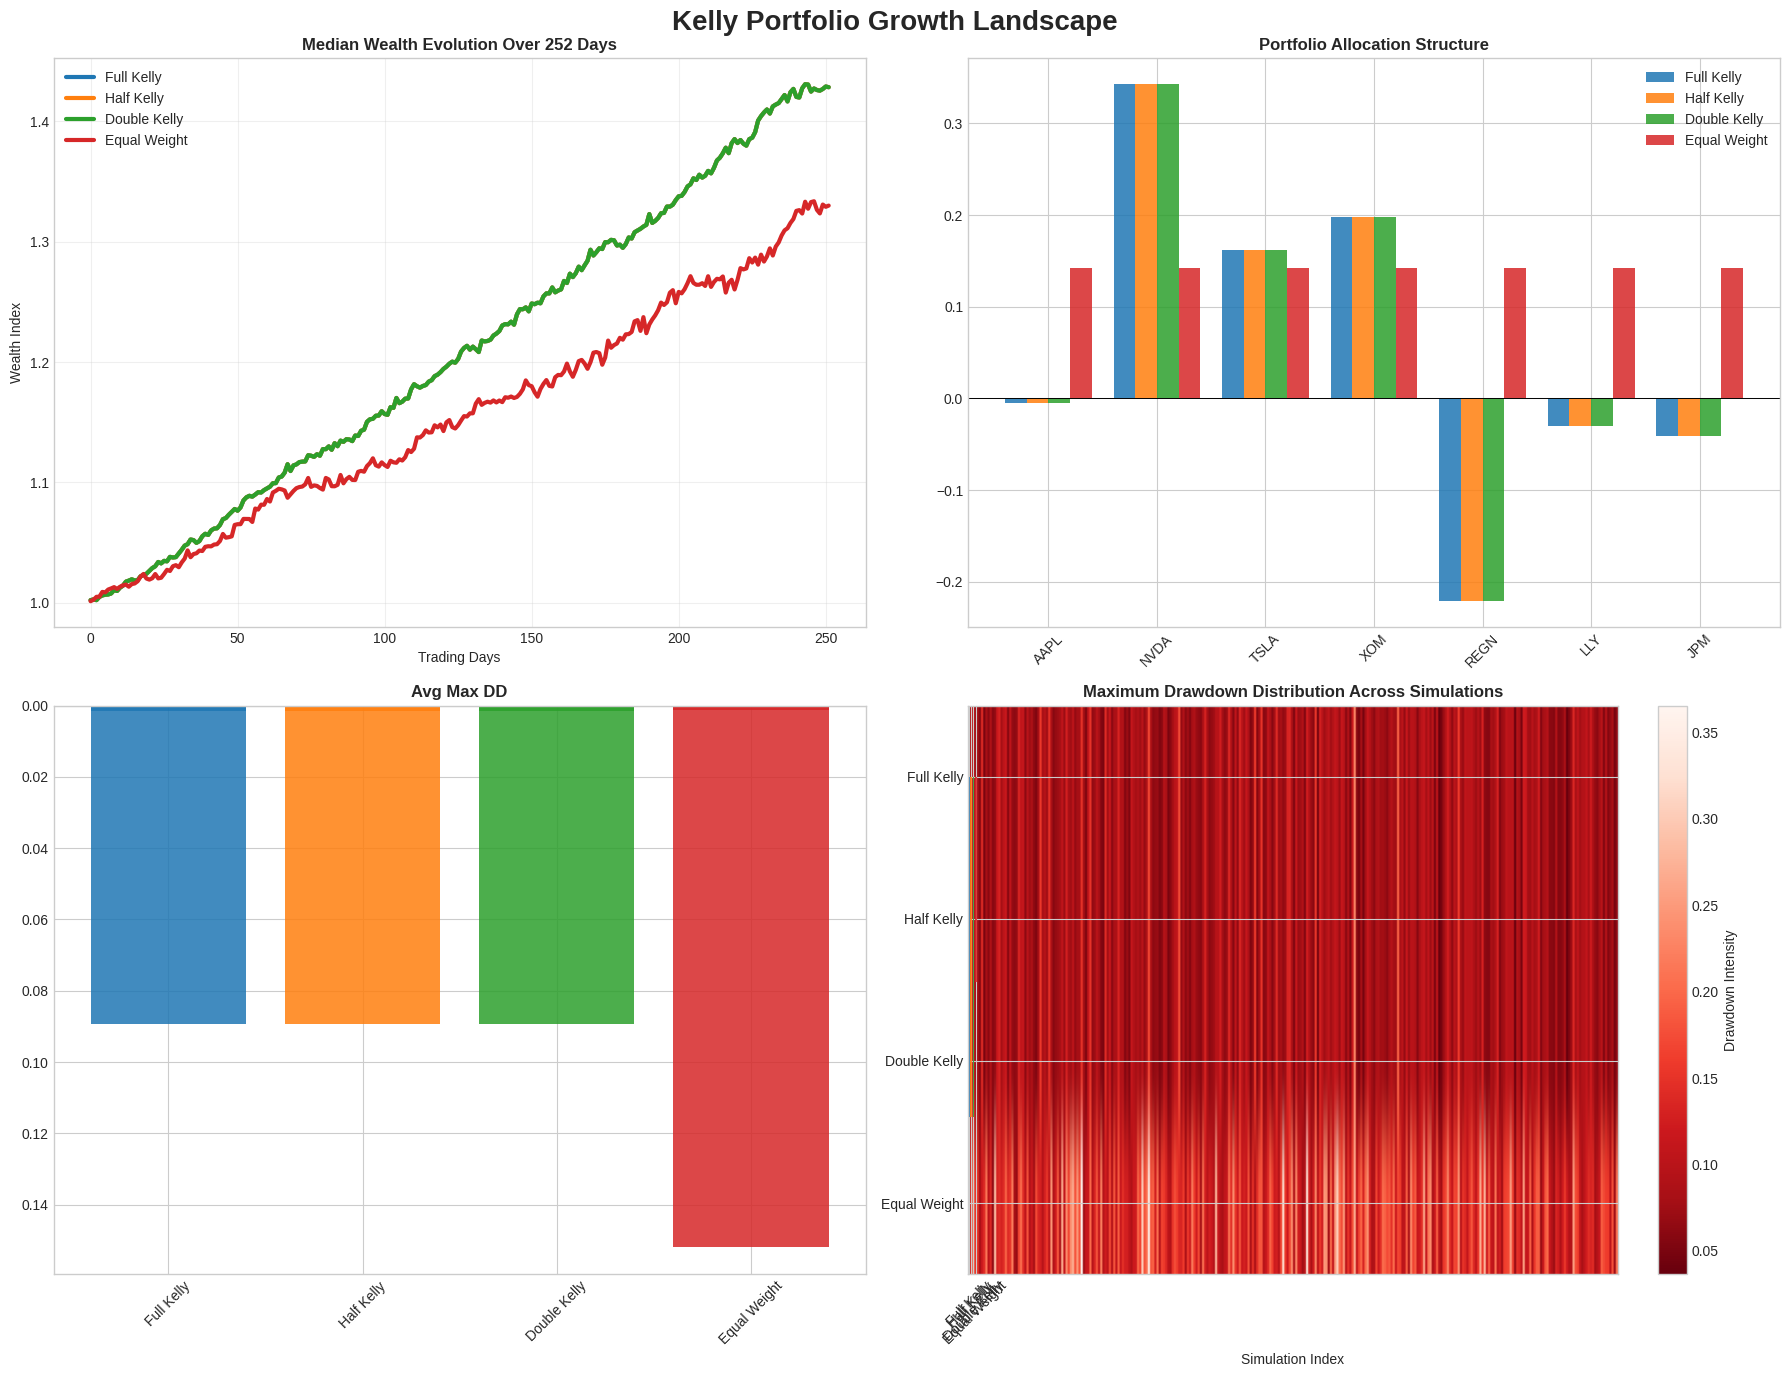

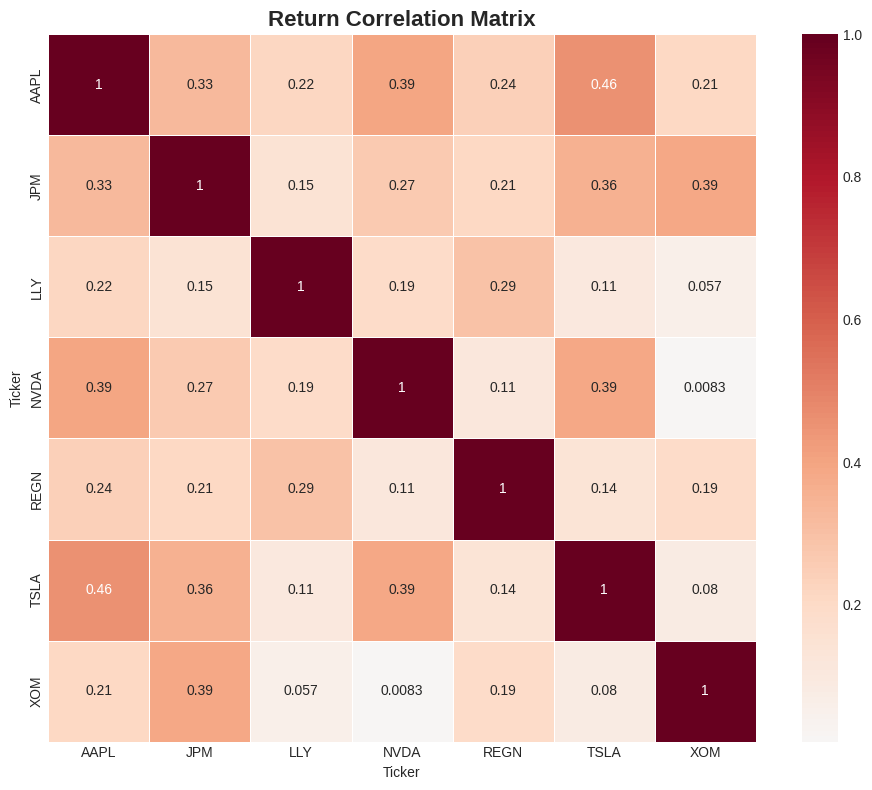

In [26]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import inv
import warnings
warnings.filterwarnings('ignore')

symbol_pack = ['AAPL', 'NVDA', 'TSLA', 'XOM', 'REGN', 'LLY', 'JPM']
time_left = '2023-01-01'
time_right = '2025-07-01'

download_block = yf.download(
    symbol_pack,
    start=time_left,
    end=time_right,
    auto_adjust=True,
    progress=False
)

if isinstance(download_block.columns, pd.MultiIndex):
    close_sheet = download_block.xs('Close', axis=1, level=0)
else:
    close_sheet = download_block

close_sheet = close_sheet.dropna(how='any')

log_matrix = np.log(close_sheet / close_sheet.shift(1)).dropna()

drift_lane = log_matrix.mean().values
cov_lattice = log_matrix.cov().values

rf_anchor = 0.0
excess_lane = drift_lane - rf_anchor

days_year = 252
vol_scale = np.sqrt(days_year)

annual_geo = np.exp(drift_lane * days_year) - 1.0
annual_vol = log_matrix.std().values * vol_scale

print("Annualized characteristics:")
for i, tag in enumerate(symbol_pack):
    print(f"{tag}: geo={annual_geo[i]:.2%}, vol={annual_vol[i]:.2%}")

def growth_engine(weight_vector, drift_vector, cov_matrix, sim_size=12000, horizon=252):
    shock_cube = np.random.multivariate_normal(
        drift_vector,
        cov_matrix,
        size=(sim_size, horizon)
    )
    portfolio_wave = np.einsum('ijk,k->ij', shock_cube, weight_vector)
    wealth_surface = np.cumprod(1.0 + portfolio_wave, axis=1)
    terminal_line = wealth_surface[:, -1]
    geo_score = np.mean(terminal_line ** (1.0 / horizon) - 1.0)
    crest_map = np.maximum.accumulate(wealth_surface, axis=1)
    draw_map = (crest_map - wealth_surface) / crest_map
    avg_max_dd = np.mean(np.max(draw_map, axis=1))
    sharpe_score = (weight_vector @ drift_vector) / np.sqrt(weight_vector @ cov_matrix @ weight_vector) * vol_scale
    return geo_score, sharpe_score, avg_max_dd

precision_shell = inv(cov_lattice)
raw_kelly_line = precision_shell @ excess_lane
kelly_spine = raw_kelly_line / np.sum(np.abs(raw_kelly_line))

half_spine = 0.5 * kelly_spine
half_spine = half_spine / np.sum(np.abs(half_spine))

double_spine = 2.0 * kelly_spine
double_spine = double_spine / np.sum(np.abs(double_spine))

allocation_map = {
    'Full Kelly': kelly_spine,
    'Half Kelly': half_spine,
    'Double Kelly': double_spine,
    'Equal Weight': np.ones(len(symbol_pack)) / len(symbol_pack)
}

metric_map = {}
for label, vec in allocation_map.items():
    g, s, d = growth_engine(vec, excess_lane, cov_lattice)
    metric_map[label] = {'Geo Growth': g, 'Sharpe': s, 'Avg Max DD': d}

metric_frame = pd.DataFrame(metric_map).T.round(4)
print("\nStrategy metrics:")
print(metric_frame)

weight_frame = pd.DataFrame(allocation_map, index=symbol_pack).round(4)
print("\nWeight profiles:")
print(weight_frame)

viz_sims = 300
viz_horizon = 252

viz_cube = np.random.multivariate_normal(
    excess_lane,
    cov_lattice,
    size=(viz_sims, viz_horizon)
)

median_tracks = {}
for label, vec in allocation_map.items():
    port_stream = np.einsum('ijk,k->ij', viz_cube, vec)
    wealth_paths = np.cumprod(1.0 + port_stream, axis=1)
    median_tracks[label] = np.median(wealth_paths, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Kelly Portfolio Growth Landscape', fontsize=20, fontweight='bold')

color_stack = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for label, col in zip(median_tracks.keys(), color_stack):
    axes[0, 0].plot(median_tracks[label], lw=3, color=col, label=label)

axes[0, 0].set_title('Median Wealth Evolution Over 252 Days', fontweight='bold')
axes[0, 0].set_xlabel('Trading Days')
axes[0, 0].set_ylabel('Wealth Index')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

bar_axis = np.arange(len(symbol_pack))
bar_width = 0.2
for i, (label, vec) in enumerate(allocation_map.items()):
    axes[0, 1].bar(bar_axis + i * bar_width, vec, bar_width, color=color_stack[i], alpha=0.85, label=label)

axes[0, 1].set_title('Portfolio Allocation Structure', fontweight='bold')
axes[0, 1].set_xticks(bar_axis + bar_width * 1.5)
axes[0, 1].set_xticklabels(symbol_pack, rotation=45)
axes[0, 1].axhline(0.0, color='black', lw=0.7)
axes[0, 1].legend()

metric_keys = ['Geo Growth', 'Sharpe', 'Avg Max DD']
for j, key in enumerate(metric_keys):
    vals = [metric_map[k][key] for k in metric_map]
    axes[1, j % 2].bar(metric_map.keys(), vals, color=color_stack, alpha=0.85)
    axes[1, j % 2].set_title(key, fontweight='bold')
    axes[1, j % 2].tick_params(axis='x', rotation=45)
    if key == 'Avg Max DD':
        axes[1, j % 2].invert_yaxis()

dd_grid = np.zeros((len(allocation_map), viz_sims))
labels = list(allocation_map.keys())

for i, (label, vec) in enumerate(allocation_map.items()):
    port_stream = np.einsum('ijk,k->ij', viz_cube, vec)
    wealth_paths = np.cumprod(1.0 + port_stream, axis=1)
    peaks = np.maximum.accumulate(wealth_paths, axis=1)
    dd_grid[i] = np.max((peaks - wealth_paths) / peaks, axis=1)

heat_layer = axes[1, 1].imshow(dd_grid, cmap='Reds_r', aspect='auto')
axes[1, 1].set_yticks(np.arange(len(labels)))
axes[1, 1].set_yticklabels(labels)
axes[1, 1].set_title('Maximum Drawdown Distribution Across Simulations', fontweight='bold')
axes[1, 1].set_xlabel('Simulation Index')
plt.colorbar(heat_layer, ax=axes[1, 1], label='Drawdown Intensity')

plt.tight_layout()
plt.show()

corr_matrix = log_matrix.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0.0, square=True, linewidths=0.6)
plt.title('Return Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**FOOTNOTE**

Advantage for using AI: Needing less time to collect information and to evaluate it for accuracy as compared to using bibliographical research.